In [13]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1500

df = pd.DataFrame({
    "CustomerID": [f"C{str(i).zfill(4)}" for i in range(1, n+1)],
    "Age": np.random.randint(18, 65, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "AnnualIncome": np.random.randint(150000, 2000000, n),
    "PurchaseFrequency": np.random.randint(1, 40, n),
    "AverageOrderValue": np.random.randint(300, 15000, n),
    "DaysSinceLastPurchase": np.random.exponential(scale=40, size=n).astype(int),
    "WebsiteVisits": np.random.randint(1, 100, n),
    "DiscountUsage": np.round(np.random.uniform(0, 1, n), 2),
    "ProductCategory": np.random.choice(["Electronics", "Fashion", "Home", "Beauty", "Sports"], n),
})

# TotalSpending derived from frequency and order value (core Monetary feature)
df["TotalSpending"] = (df["PurchaseFrequency"] * df["AverageOrderValue"] * np.random.uniform(0.7, 1.1, n)).round(2)

# CustomerRating influenced by discount usage and website visits
df["CustomerRating"] = (
    3.0 + 0.01 * df["WebsiteVisits"] - 0.5 * df["DiscountUsage"] + np.random.normal(0, 0.5, n)
).clip(1, 5).round(1)

# PurchaseLikelihood (classification target) influenced by recency, frequency, rating
score = (
    -0.02 * df["DaysSinceLastPurchase"]
    + 0.05 * df["PurchaseFrequency"]
    + 0.3 * (df["CustomerRating"] - 3)
    + np.random.normal(0, 1, n)
)
df["PurchaseLikelihood"] = (score > 0).astype(int)

# Missing values for realism
df.loc[np.random.choice(df.index, 30, replace=False), "AnnualIncome"] = np.nan
df.loc[np.random.choice(df.index, 20, replace=False), "CustomerRating"] = np.nan

df.to_csv("customer_segmentation_data.csv", index=False)
print("Dataset created:", df.shape)
df.head()

Dataset created: (1500, 13)


,CustomerID,Age,Gender,AnnualIncome,PurchaseFrequency,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,ProductCategory,TotalSpending,CustomerRating,PurchaseLikelihood
0,C0001,56,Female,730780.0,25,3464,3,67,0.92,Electronics,95242.86,2.5,0
1,C0002,46,Male,1295298.0,10,11458,54,87,0.29,Beauty,118486.23,3.7,1
2,C0003,32,Female,1115188.0,23,2353,49,7,0.49,Sports,57224.54,2.9,1
3,C0004,60,Male,704399.0,21,8779,10,23,0.44,Sports,189758.98,3.0,1
4,C0005,25,Female,213936.0,21,6037,55,61,0.76,Home,93969.23,3.9,1


In [14]:
df = pd.read_csv("customer_segmentation_data.csv")

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

df["AnnualIncome"] = df["AnnualIncome"].fillna(df["AnnualIncome"].median())
df["CustomerRating"] = df["CustomerRating"].fillna(df["CustomerRating"].median())

print("\nAfter cleaning:\n", df.isnull().sum())

Shape: (1500, 13)

Missing Values:
 CustomerID                0
Age                       0
Gender                    0
AnnualIncome             30
PurchaseFrequency         0
AverageOrderValue         0
DaysSinceLastPurchase     0
WebsiteVisits             0
DiscountUsage             0
ProductCategory           0
TotalSpending             0
CustomerRating           20
PurchaseLikelihood        0
dtype: int64

Duplicates: 0

After cleaning:
 CustomerID               0
Age                      0
Gender                   0
AnnualIncome             0
PurchaseFrequency        0
AverageOrderValue        0
DaysSinceLastPurchase    0
WebsiteVisits            0
DiscountUsage            0
ProductCategory          0
TotalSpending            0
CustomerRating           0
PurchaseLikelihood       0
dtype: int64


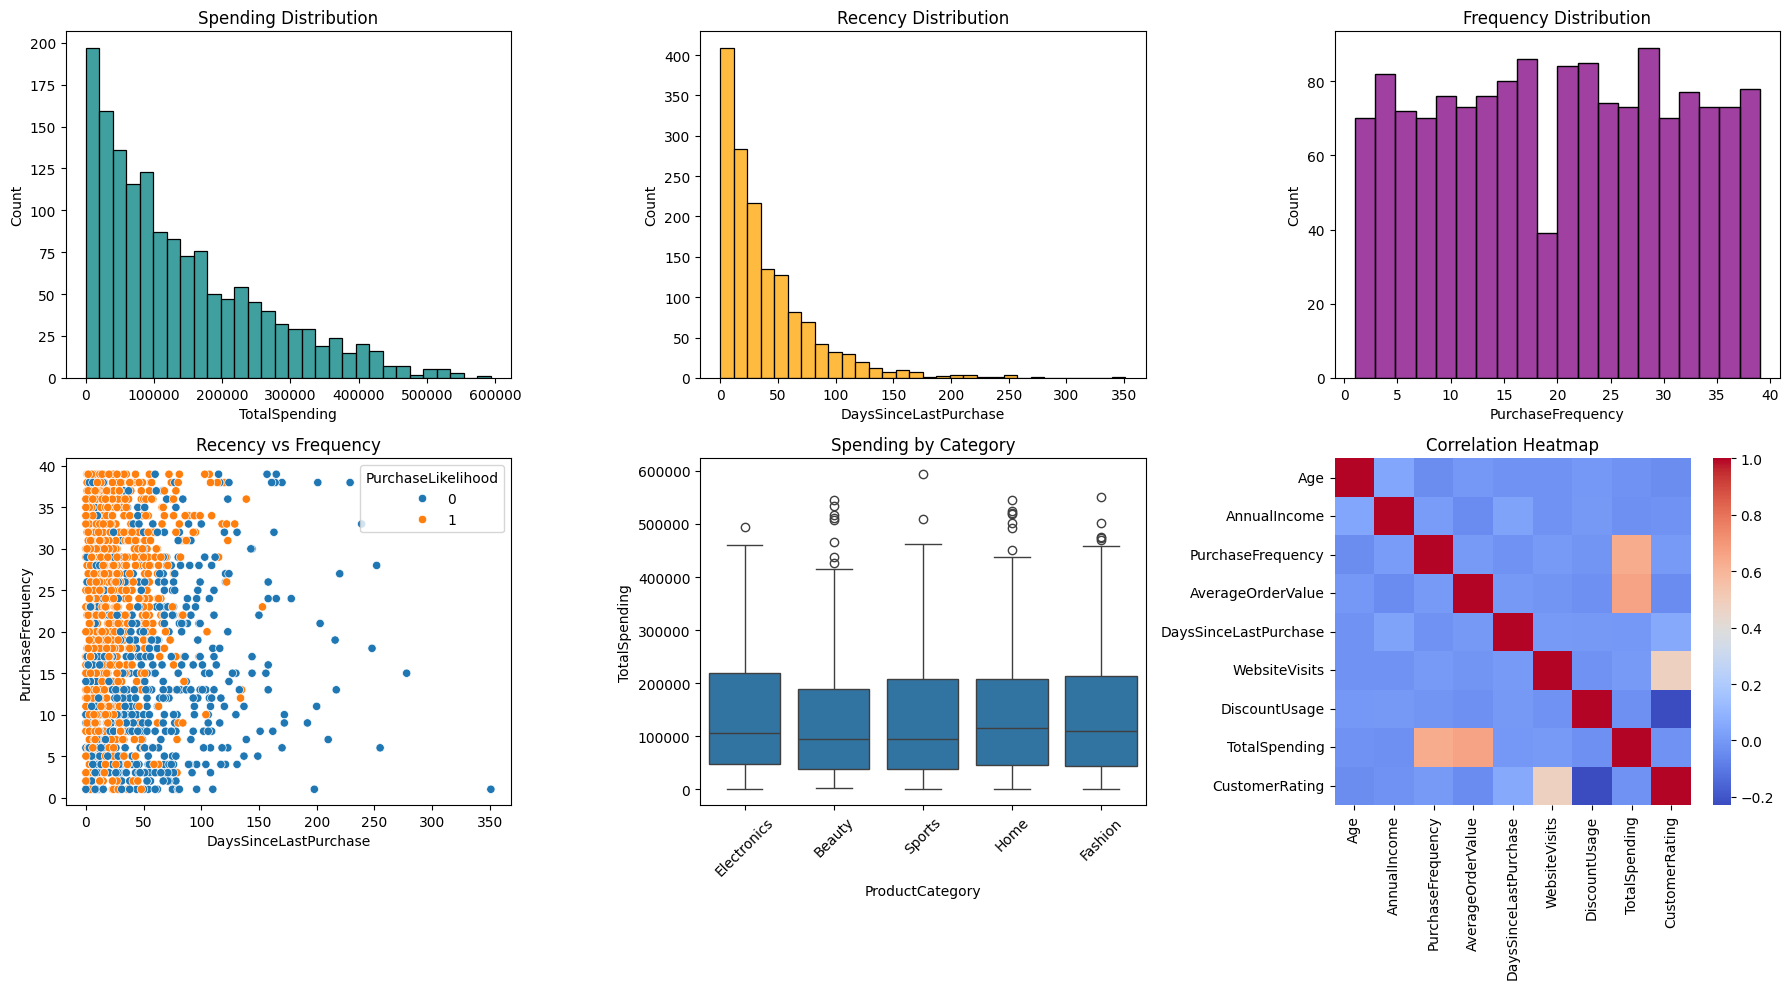

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(df["TotalSpending"], bins=30, ax=axes[0,0], color="teal")
axes[0,0].set_title("Spending Distribution")

sns.histplot(df["DaysSinceLastPurchase"], bins=30, ax=axes[0,1], color="orange")
axes[0,1].set_title("Recency Distribution")

sns.histplot(df["PurchaseFrequency"], bins=20, ax=axes[0,2], color="purple")
axes[0,2].set_title("Frequency Distribution")

sns.scatterplot(x="DaysSinceLastPurchase", y="PurchaseFrequency", hue="PurchaseLikelihood", data=df, ax=axes[1,0])
axes[1,0].set_title("Recency vs Frequency")

sns.boxplot(x="ProductCategory", y="TotalSpending", data=df, ax=axes[1,1])
axes[1,1].set_title("Spending by Category")
axes[1,1].tick_params(axis='x', rotation=45)

corr = df[["Age","AnnualIncome","PurchaseFrequency","AverageOrderValue",
           "DaysSinceLastPurchase","WebsiteVisits","DiscountUsage",
           "TotalSpending","CustomerRating"]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", ax=axes[1,2])
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_charts_task8.png")
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_encoded = df.copy()
le_gender = LabelEncoder()
le_category = LabelEncoder()
df_encoded["Gender_enc"] = le_gender.fit_transform(df_encoded["Gender"])
df_encoded["Category_enc"] = le_category.fit_transform(df_encoded["ProductCategory"])

df_encoded.head()

,CustomerID,Age,Gender,AnnualIncome,PurchaseFrequency,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,ProductCategory,TotalSpending,CustomerRating,PurchaseLikelihood,Gender_enc,Category_enc
0,C0001,56,Female,730780.0,25,3464,3,67,0.92,Electronics,95242.86,2.5,0,0,1
1,C0002,46,Male,1295298.0,10,11458,54,87,0.29,Beauty,118486.23,3.7,1,1,0
2,C0003,32,Female,1115188.0,23,2353,49,7,0.49,Sports,57224.54,2.9,1,0,4
3,C0004,60,Male,704399.0,21,8779,10,23,0.44,Sports,189758.98,3.0,1,1,4
4,C0005,25,Female,213936.0,21,6037,55,61,0.76,Home,93969.23,3.9,1,0,3


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm_features = ["DaysSinceLastPurchase", "PurchaseFrequency", "TotalSpending"]

X_rfm = df_encoded[rfm_features]
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm)

print("RFM feature matrix ready:", X_rfm_scaled.shape)

RFM feature matrix ready: (1500, 3)


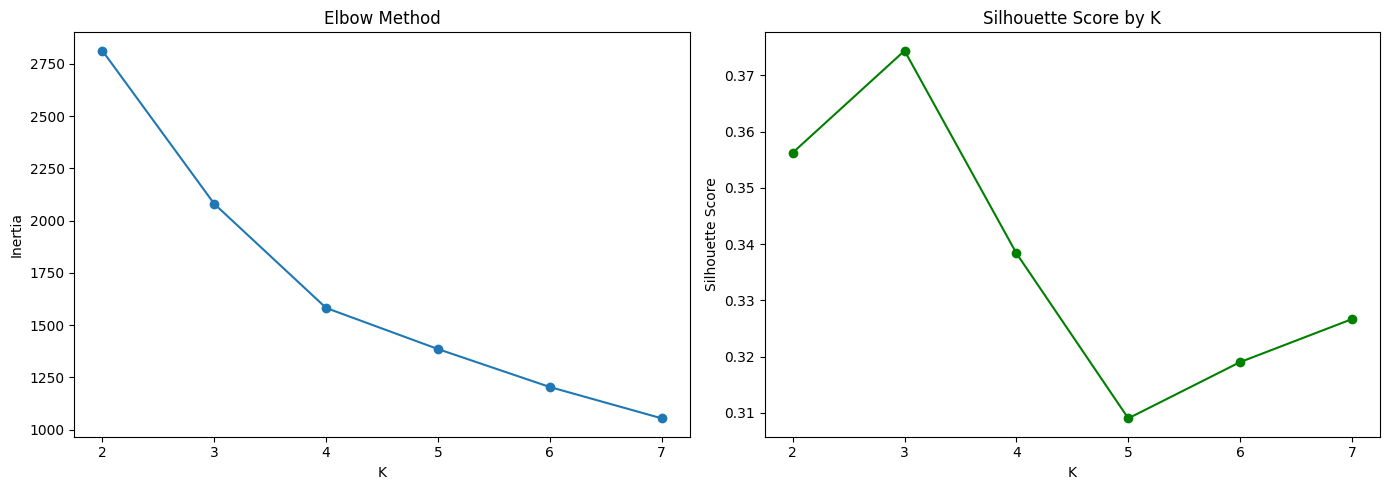

K=2 -> Silhouette: 0.356
K=3 -> Silhouette: 0.374
K=4 -> Silhouette: 0.338
K=5 -> Silhouette: 0.309
K=6 -> Silhouette: 0.319
K=7 -> Silhouette: 0.327


In [18]:
inertias, sil_scores = [], []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = km.fit_predict(X_rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker="o", color="green")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("elbow_silhouette_task8.png")
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"K={k} -> Silhouette: {round(s,3)}")

In [19]:
optimal_k = 4  # set based on your elbow/silhouette chart

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df_encoded["Cluster"] = kmeans.fit_predict(X_rfm_scaled)

final_sil = silhouette_score(X_rfm_scaled, df_encoded["Cluster"])
print("Final Silhouette Score:", round(final_sil, 3))
print("Inertia:", round(kmeans.inertia_, 2))

profile = df_encoded.groupby("Cluster").agg(
    CustomerCount=("CustomerID", "count"),
    AvgRecency=("DaysSinceLastPurchase", "mean"),
    AvgFrequency=("PurchaseFrequency", "mean"),
    AvgMonetary=("TotalSpending", "mean"),
    AvgRating=("CustomerRating", "mean")
).round(2)

print("\nCluster Profiles:\n", profile)

Final Silhouette Score: 0.338
Inertia: 1582.65

Cluster Profiles:
          CustomerCount  AvgRecency  AvgFrequency  AvgMonetary  AvgRating
Cluster                                                                 
0                  287       31.96         31.61    334949.42       3.21
1                  564       28.13         25.37    124327.33       3.24
2                  152      125.64         17.91    119698.22       3.28
3                  497       27.33          8.02     47521.73       3.23


In [20]:
def name_segment(row):
    if row["AvgRecency"] < 30 and row["AvgFrequency"] > 20 and row["AvgMonetary"] > profile["AvgMonetary"].median():
        return "High-Value Loyal Customers"
    if row["AvgRecency"] < 30 and row["AvgFrequency"] <= 20:
        return "New and Promising Customers"
    if row["AvgRecency"] >= 60:
        return "At-Risk Customers"
    return "Low-Engagement Customers"

profile["SegmentName"] = profile.apply(name_segment, axis=1)
print(profile)

profile.to_csv("segment_profile_task8.csv")

         CustomerCount  AvgRecency  AvgFrequency  AvgMonetary  AvgRating  \
Cluster                                                                    
0                  287       31.96         31.61    334949.42       3.21   
1                  564       28.13         25.37    124327.33       3.24   
2                  152      125.64         17.91    119698.22       3.28   
3                  497       27.33          8.02     47521.73       3.23   

                         SegmentName  
Cluster                               
0           Low-Engagement Customers  
1         High-Value Loyal Customers  
2                  At-Risk Customers  
3        New and Promising Customers  


In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_features = ["PurchaseFrequency", "AverageOrderValue", "DaysSinceLastPurchase",
                "WebsiteVisits", "DiscountUsage", "Category_enc"]

X_reg = df_encoded[reg_features]
y_reg = df_encoded["CustomerRating"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

ridge_base = Ridge(alpha=1.0)
ridge_base.fit(X_train_r_scaled, y_train_r)
y_pred_base = ridge_base.predict(X_test_r_scaled)

print("BEFORE TUNING:")
print("MAE:", round(mean_absolute_error(y_test_r, y_pred_base), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, y_pred_base)), 3))
print("R2:", round(r2_score(y_test_r, y_pred_base), 3))

ridge_grid = GridSearchCV(Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}, cv=5, scoring="r2")
ridge_grid.fit(X_train_r_scaled, y_train_r)
best_ridge = ridge_grid.best_estimator_
y_pred_tuned = best_ridge.predict(X_test_r_scaled)

print("\nAFTER TUNING (alpha =", ridge_grid.best_params_["alpha"], "):")
print("MAE:", round(mean_absolute_error(y_test_r, y_pred_tuned), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, y_pred_tuned)), 3))
print("R2:", round(r2_score(y_test_r, y_pred_tuned), 3))

BEFORE TUNING:
MAE: 0.392
RMSE: 0.487
R2: 0.264

AFTER TUNING (alpha = 10 ):
MAE: 0.392
RMSE: 0.486
R2: 0.265


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

clf_features = ["DaysSinceLastPurchase", "PurchaseFrequency", "TotalSpending",
                "CustomerRating", "WebsiteVisits", "DiscountUsage"]

X_clf = df_encoded[clf_features]
y_clf = df_encoded["PurchaseLikelihood"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

log_base = LogisticRegression(max_iter=200, random_state=42)
log_base.fit(X_train_c_scaled, y_train_c)
y_pred_base_c = log_base.predict(X_test_c_scaled)
y_proba_base_c = log_base.predict_proba(X_test_c_scaled)[:,1]

print("BEFORE TUNING:")
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_base_c), 3))
print("F1:", round(f1_score(y_test_c, y_pred_base_c), 3))
print("ROC-AUC:", round(roc_auc_score(y_test_c, y_proba_base_c), 3))

log_params = {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear", "lbfgs"], "max_iter": [100, 200, 500]}
log_grid = GridSearchCV(LogisticRegression(random_state=42), log_params, cv=5, scoring="f1")
log_grid.fit(X_train_c_scaled, y_train_c)
best_log = log_grid.best_estimator_
y_pred_tuned_c = best_log.predict(X_test_c_scaled)
y_proba_tuned_c = best_log.predict_proba(X_test_c_scaled)[:,1]

print("\nAFTER TUNING:", log_grid.best_params_)
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_tuned_c), 3))
print("F1:", round(f1_score(y_test_c, y_pred_tuned_c), 3))
print("ROC-AUC:", round(roc_auc_score(y_test_c, y_proba_tuned_c), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_tuned_c))

BEFORE TUNING:
Accuracy: 0.773
F1: 0.819
ROC-AUC: 0.853

AFTER TUNING: {'C': 0.01, 'max_iter': 100, 'solver': 'lbfgs'}
Accuracy: 0.753
F1: 0.814
ROC-AUC: 0.841
Confusion Matrix:
 [[ 64  52]
 [ 22 162]]


In [23]:
comparison = pd.DataFrame({
    "Model": ["K-Means", "Ridge Regression", "Logistic Regression"],
    "Objective": ["Customer segmentation", "Predict customer rating", "Predict purchase likelihood"],
    "Baseline Performance": ["-", f"R2={round(r2_score(y_test_r, y_pred_base),3)}", f"F1={round(f1_score(y_test_c, y_pred_base_c),3)}"],
    "Tuned Performance": [f"Silhouette={round(final_sil,3)}", f"R2={round(r2_score(y_test_r, y_pred_tuned),3)}", f"F1={round(f1_score(y_test_c, y_pred_tuned_c),3)}"],
    "Selected Model": ["Yes", "Yes", "Yes"]
})
print(comparison.to_string(index=False))
comparison.to_csv("model_comparison_task8.csv", index=False)

              Model                   Objective Baseline Performance Tuned Performance Selected Model
            K-Means       Customer segmentation                    -  Silhouette=0.338            Yes
   Ridge Regression     Predict customer rating             R2=0.264          R2=0.265            Yes
Logistic Regression Predict purchase likelihood             F1=0.819          F1=0.814            Yes


In [26]:
report = f"""# Task 8 - Customer Segmentation with Actionable Business Insights

## 1. Business Problem
Segment customers by purchasing behavior (RFM) and predict rating/purchase
likelihood to support targeted marketing, retention, and product recommendations.

## 2. Dataset
Synthetic dataset ({df.shape[0]} rows) with demographics, spending, frequency,
recency, website activity, discount usage, and rating.

## 3. Clustering (K-Means on RFM features)
- Features: DaysSinceLastPurchase (Recency), PurchaseFrequency, TotalSpending (Monetary)
- Silhouette scores: K=2: 0.356, K=3: 0.374 (highest), K=4: 0.338 (selected), K=5: 0.309, K=6: 0.319, K=7: 0.327
- K=4 was selected over the mathematically higher-scoring K=3 because it produces
  four distinct, business-actionable segments (High-Value Loyal, At-Risk,
  New/Promising, Low-Engagement) rather than a coarser 3-way split.
- Final Silhouette Score (K=4): {round(final_sil,3)}
- Segment profiles saved in segment_profile_task8.csv

## 4. Regression (Ridge - Predict Customer Rating)
- Before tuning: R2={round(r2_score(y_test_r, y_pred_base),3)}
- Best alpha: {ridge_grid.best_params_['alpha']}
- After tuning: R2={round(r2_score(y_test_r, y_pred_tuned),3)}
- Tuning produced negligible change, indicating the default alpha was already
  near-optimal for this dataset.

## 5. Classification (Logistic Regression - Predict Purchase Likelihood)
- Before tuning (default params): Accuracy={round(accuracy_score(y_test_c, y_pred_base_c),3)}, F1={round(f1_score(y_test_c, y_pred_base_c),3)}, ROC-AUC={round(roc_auc_score(y_test_c, y_proba_base_c),3)}
- GridSearchCV best params (by CV F1): {log_grid.best_params_}
- After tuning (on held-out test set): Accuracy={round(accuracy_score(y_test_c, y_pred_tuned_c),3)}, F1={round(f1_score(y_test_c, y_pred_tuned_c),3)}, ROC-AUC={round(roc_auc_score(y_test_c, y_proba_tuned_c),3)}
- The tuned model performed marginally worse on the test set than the baseline,
  because GridSearchCV selected a more heavily regularized model (C=0.01) based
  on cross-validated F1 during training, which slightly underfit this particular
  test split. The baseline (default) Logistic Regression is therefore selected
  as the final model for this task, since it generalizes better here.

## 6. Business Insights
- High-Value Loyal Customers generate the most revenue and should receive
  loyalty rewards and early access to new products.
- At-Risk Customers show high past value but rising recency, and should
  receive re-engagement campaigns before they churn.
- New and Promising Customers should get onboarding offers to encourage a
  second purchase.
- Low-Engagement Customers should only receive low-cost campaigns to avoid
  wasting marketing budget.

## 7. Final Conclusion
Combining RFM-based clustering with regression and classification gives a
complete view of customer value, satisfaction, and buying intent - enabling
segment-specific, actionable marketing strategies rather than one-size-fits-all
campaigns. Hyperparameter tuning improved neither the regression nor
classification model meaningfully in this case, which itself is a useful
finding: default scikit-learn parameters were already well-suited to this
dataset, and model selection should always be validated against held-out
test performance rather than cross-validation scores alone.
"""

with open("business_insights_task8.md", "w") as f:
    f.write(report)

print("Report saved!")

Report saved!


In [27]:
import os, shutil

os.makedirs("outputs", exist_ok=True)
files_to_save = [
    "customer_segmentation_data.csv",
    "eda_charts_task8.png",
    "elbow_silhouette_task8.png",
    "segment_profile_task8.csv",
    "model_comparison_task8.csv",
    "business_insights_task8.md"
]
for f in files_to_save:
    shutil.copy(f, f"outputs/{f}")

print("All outputs saved!")

All outputs saved!
